In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt


from qiskit import transpile
from qiskit.circuit import Parameter,ParameterExpression
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit.circuit.library import QAOAAnsatz
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime.fake_provider import FakeMumbaiV2
from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit_optimization.applications import Knapsack
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit.circuit.library import QAOAAnsatz
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

import sys
sys.path.append("../")
from clapton.clapton import claptonize
from clapton.circuit_manipulation import transform_to_allowed_gates,qiskit_to_stim, modify_circuit, multi_angle_qaoa_circuit, generate_qiskit_param_map,relax_qaoa_parameters
from testing_scripts.qaoa_utils import evaluate_energy, QAOASolver
from testing_scripts.knapsack_utils import generate_knapsack_instance

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [2]:
# prob = Knapsack(values=[3, 4, 5, 6, 7,8,9,10,11,12], weights=[2, 3, 4, 5, 6,7,8,9,10,11], max_weight=10)

# Example usage
prob = generate_knapsack_instance(num_items=6,seed=2)

In [3]:
# prob = Knapsack(values=[3, 4, 5, 6, 7,8,9,10,11,12], weights=[2, 3, 4, 5, 6,7,8,9,10,11], max_weight=10)
qp = prob.to_quadratic_program()
print(qp.prettyprint())

Problem name: Knapsack

Maximize
  2*x_0 + 3*x_1 + 3*x_2 + 12*x_3 + 6*x_4 + 10*x_5

Subject to
  Linear constraints (1)
    5*x_0 + 10*x_1 + 4*x_2 + 10*x_3 + x_4 + 10*x_5 <= 20  'c0'

  Binary variables (6)
    x_0 x_1 x_2 x_3 x_4 x_5



In [4]:
# intermediate QUBO form of the optimization problem
conv = QuadraticProgramToQubo()
qubo = conv.convert(qp)
print(qubo.prettyprint())

Problem name: Knapsack

Minimize
  37*c0@int_slack@0^2 + 148*c0@int_slack@0*c0@int_slack@1
  + 296*c0@int_slack@0*c0@int_slack@2 + 592*c0@int_slack@0*c0@int_slack@3
  + 370*c0@int_slack@0*c0@int_slack@4 + 148*c0@int_slack@1^2
  + 592*c0@int_slack@1*c0@int_slack@2 + 1184*c0@int_slack@1*c0@int_slack@3
  + 740*c0@int_slack@1*c0@int_slack@4 + 592*c0@int_slack@2^2
  + 2368*c0@int_slack@2*c0@int_slack@3 + 1480*c0@int_slack@2*c0@int_slack@4
  + 2368*c0@int_slack@3^2 + 2960*c0@int_slack@3*c0@int_slack@4
  + 925*c0@int_slack@4^2 + 370*x_0*c0@int_slack@0 + 740*x_0*c0@int_slack@1
  + 1480*x_0*c0@int_slack@2 + 2960*x_0*c0@int_slack@3 + 1850*x_0*c0@int_slack@4
  + 925*x_0^2 + 3700*x_0*x_1 + 1480*x_0*x_2 + 3700*x_0*x_3 + 370*x_0*x_4
  + 3700*x_0*x_5 + 740*x_1*c0@int_slack@0 + 1480*x_1*c0@int_slack@1
  + 2960*x_1*c0@int_slack@2 + 5920*x_1*c0@int_slack@3 + 3700*x_1*c0@int_slack@4
  + 3700*x_1^2 + 2960*x_1*x_2 + 7400*x_1*x_3 + 740*x_1*x_4 + 7400*x_1*x_5
  + 296*x_2*c0@int_slack@0 + 592*x_2*c0@int_slack

In [5]:
# qubit Hamiltonian and offset
op, offset = qubo.to_ising()
print(f"num qubits: {op.num_qubits}, offset: {offset}\n")
print(op)
cost_hamiltonian = op

num qubits: 11, offset: 7863.0

SparsePauliOp(['IIIIIIIIIIZ', 'IIIIIIIIIZI', 'IIIIIIIIZII', 'IIIIIIIZIII', 'IIIIIIZIIII', 'IIIIIZIIIII', 'IIIIZIIIIII', 'IIIZIIIIIII', 'IIZIIIIIIII', 'IZIIIIIIIII', 'ZIIIIIIIIII', 'IIIIIIIIIZZ', 'IIIIIIIIZIZ', 'IIIIIIIZIIZ', 'IIIIIIZIIIZ', 'IIIIIZIIIIZ', 'IIIIZIIIIIZ', 'IIIZIIIIIIZ', 'IIZIIIIIIIZ', 'IZIIIIIIIIZ', 'ZIIIIIIIIIZ', 'IIIIIIIIZZI', 'IIIIIIIZIZI', 'IIIIIIZIIZI', 'IIIIIZIIIZI', 'IIIIZIIIIZI', 'IIIZIIIIIZI', 'IIZIIIIIIZI', 'IZIIIIIIIZI', 'ZIIIIIIIIZI', 'IIIIIIIZZII', 'IIIIIIZIZII', 'IIIIIZIIZII', 'IIIIZIIIZII', 'IIIZIIIIZII', 'IIZIIIIIZII', 'IZIIIIIIZII', 'ZIIIIIIIZII', 'IIIIIIZZIII', 'IIIIIZIZIII', 'IIIIZIIZIII', 'IIIZIIIZIII', 'IIZIIIIZIII', 'IZIIIIIZIII', 'ZIIIIIIZIII', 'IIIIIZZIIII', 'IIIIZIZIIII', 'IIIZIIZIIII', 'IIZIIIZIIII', 'IZIIIIZIIII', 'ZIIIIIZIIII', 'IIIIZZIIIII', 'IIIZIZIIIII', 'IIZIIZIIIII', 'IZIIIZIIIII', 'ZIIIIZIIIII', 'IIIZZIIIIII', 'IIZIZIIIIII', 'IZIIZIIIIII', 'ZIIIZIIIIII', 'IIZZIIIIIII', 'IZIZIIIIIII', 'ZIIZIIIIIII', 'IZZIIII

In [6]:
reps=2
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)

In [7]:
knapsack_qaoa = QAOASolver(cost_hamiltonian,circuit)
knapsack_qaoa.prepare_circuit()

In [ ]:
# Run CAFQA Process
knapsack_qaoa.run_CAFQA(n_gens=10)

STARTING ROUND 0


started GA at id 1 with 1 procs

started GA at id 2 with 1 procs


started GA at id 3 with 1 procs
GA parameters used for this experiment:
  num_generations=5
  num_parents_mating=20
  population_size=100
  num_genes=154
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5started GA at id None with 1 procs

GA parameters used for this experiment:
  num_generations=5
  num_parents_mating=20
  population_size=100
  num_genes=154
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5

GA parameters used for this experiment:
  num_generations=5
  num_parents_mating=20
  population_size=100
  num_genes=154
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=ada

In [9]:
knapsack_qaoa.energy_best

np.float64(-1480.0)

In [10]:
knapsack_qaoa.evaluate_exact_energy()

Exact Energy from Eigensolver: -7886.0


np.float64(-7886.0)

In [12]:
cafqa_angles = [param * np.pi/2 for param in knapsack_qaoa.ks_best]

In [13]:
energies = [evaluate_energy(knapsack_qaoa.pcirc, cost_hamiltonian, cafqa_angles) for _ in range(10)]
average_energy = np.mean(energies)
print(f"Average CAFQA Qiskit Energy: {average_energy}")

Average CAFQA Qiskit Energy: -1485.2112060546874


In [15]:
# Random Initalization 
random_angles = np.random.random(len(knapsack_qaoa.ks_best))
random_energies = [evaluate_energy(knapsack_qaoa.pcirc, cost_hamiltonian, random_angles) for _ in range(10)]
min_energy = min(random_energies)
print(f"Minimum Energy found with Random initialization over 100 runs: {min_energy}")

Minimum Energy found with Random initialization over 100 runs: 703.5341796875


In [20]:
cafqa_result,cafqa_iteration_vals = knapsack_qaoa.run_qaoa(cafqa_angles,max_iters=10)
random_result,random_iteration_vals = knapsack_qaoa.run_qaoa(random_angles,max_iters=10)

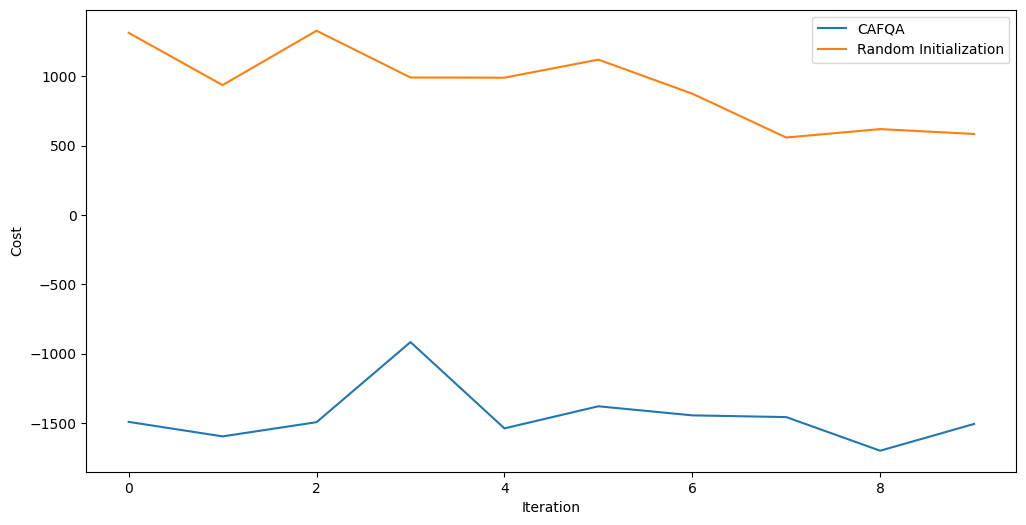

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(cafqa_iteration_vals, label="CAFQA")
plt.plot(random_iteration_vals, label="Random Initialization")
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()